# Task_Main : Abnormal User Detection, Full Pipeline

**This notebook implements the complete pipeline:**

| Stage | What |
|---|---|
| 0 | Load raw data |
| 1 | Session construction (30-min inactivity rule) |
| 2 | Feature engineering (9 feature groups, including 5 new ones) |
| 3 | Preprocessing (neutral imputation — fixes the earlier sentinel-value bug) |
| 4 | Primary model: Isolation Forest |
| 5 | Cross-validation: agreement with an independent rule-based method + LOF |
| 6 | Synthetic bot injection test (ground-truth validation + contamination tuning) |
| 7 | Business-rule override (converting users are never abnormal) |
| 8 | Event-level cleaning (only `view` events removed) |
| 9 | Reporting & export |



## Stage 0 — Setup & raw data load

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [5]:
  # <-- your dataset folder

events = pd.read_csv(f"C:\\Users\\akash\\Desktop\\dsp1t3\\events.csv")
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['visitorid'] = events['visitorid'].astype(int)
events['itemid'] = events['itemid'].astype(int)
events = events.sort_values(['visitorid', 'datetime']).reset_index(drop=True)

assert len(events) > 0, "events.csv loaded empty -- check DATA_DIR path."

print("Total events:", len(events))
print("Unique visitors:", events['visitorid'].nunique())
print(events['event'].value_counts())


Total events: 2756101
Unique visitors: 1407580
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


## Stage 1 — Session construction

Rule: a gap of **30+ minutes** of inactivity starts a new session for that visitor. This underpins several features below (session duration, intensity, and cleanly separating "gaps between visits" from "gaps between clicks within a visit").


In [6]:
SESSION_GAP_MINUTES = 30

time_diff = events.groupby('visitorid')['datetime'].diff()
is_new_session = time_diff.isna() | (time_diff > pd.Timedelta(minutes=SESSION_GAP_MINUTES))

events['session_id'] = is_new_session.groupby(events['visitorid']).cumsum()

# gap between consecutive events WITHIN the same session only (used for velocity/timing features)
events['intra_session_gap_sec'] = time_diff.where(~is_new_session).dt.total_seconds()

print("Total sessions created:", events.groupby('visitorid')['session_id'].nunique().sum())
events[['visitorid', 'datetime', 'event', 'session_id', 'intra_session_gap_sec']].head(8)


Total sessions created: 1761675


,visitorid,datetime,event,session_id,intra_session_gap_sec
0,0,2015-09-11 20:49:49.439,view,1,NaN
1,0,2015-09-11 20:52:39.591,view,1,170.152
2,0,2015-09-11 20:55:17.175,view,1,157.584
3,1,2015-08-13 17:46:06.444,view,1,NaN
4,2,2015-08-07 17:51:44.567,view,1,NaN
5,2,2015-08-07 17:53:33.790,view,1,109.223
6,2,2015-08-07 17:56:52.664,view,1,198.874
7,2,2015-08-07 18:01:08.920,view,1,256.256


### Session-level aggregation (feeds Group G features)

In [7]:
session_agg = events.groupby(['visitorid', 'session_id']).agg(
    session_start=('datetime', 'min'),
    session_end=('datetime', 'max'),
    session_events=('event', 'count')
).reset_index()
session_agg['session_duration_sec'] = (session_agg['session_end'] - session_agg['session_start']).dt.total_seconds()

user_session_features = session_agg.groupby('visitorid').agg(
    n_sessions=('session_id', 'nunique'),
    avg_session_duration=('session_duration_sec', 'mean'),
    max_session_duration=('session_duration_sec', 'max'),
    avg_events_per_session=('session_events', 'mean'),
).reset_index()

user_session_features.head()


,visitorid,n_sessions,avg_session_duration,max_session_duration,avg_events_per_session
0,0,1,327.736,327.736,3.0
1,1,1,0.000,0.000,1.0
2,2,1,1753.278,1753.278,8.0
3,3,1,0.000,0.000,1.0
4,4,1,0.000,0.000,1.0


## Stage 2 — Feature engineering (all groups)

### Groups A-C: Volume, Diversity, Conversion (carried over from earlier version, still valid)

In [8]:
base_agg = events.groupby('visitorid').agg(
    total_events=('event', 'count'),
    n_views=('event', lambda x: (x == 'view').sum()),
    n_addtocart=('event', lambda x: (x == 'addtocart').sum()),
    n_transactions=('event', lambda x: (x == 'transaction').sum()),
    unique_items=('itemid', 'nunique'),
    first_seen=('datetime', 'min'),
    last_seen=('datetime', 'max'),
).reset_index()

base_agg['active_span_days'] = (base_agg['last_seen'] - base_agg['first_seen']).dt.total_seconds() / 86400
base_agg['item_diversity_ratio'] = base_agg['unique_items'] / base_agg['total_events']
base_agg['view_to_cart_ratio'] = base_agg['n_addtocart'] / (base_agg['n_views'] + 1)
base_agg['cart_to_transaction_ratio'] = base_agg['n_transactions'] / (base_agg['n_addtocart'] + 1)

base_agg.head()


,visitorid,total_events,n_views,n_addtocart,n_transactions,unique_items,first_seen,last_seen,active_span_days,item_diversity_ratio,view_to_cart_ratio,cart_to_transaction_ratio
0,0,3,3,0,0,3,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,0.003793,1.0,0.0,0.0
1,1,1,1,0,0,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,0.000000,1.0,0.0,0.0
2,2,8,8,0,0,4,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,0.020293,0.5,0.0,0.0
3,3,1,1,0,0,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,0.000000,1.0,0.0,0.0
4,4,1,1,0,0,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,0.000000,1.0,0.0,0.0


### Group D — Velocity (fixed: only meaningful for visitors with real intra-session activity)

In [9]:
velocity = events.groupby('visitorid')['intra_session_gap_sec'].agg(['mean']).reset_index()
velocity.columns = ['visitorid', 'avg_inter_click_gap']
# NaN here means: this visitor never had 2 events close enough together to be in the same session
# -- that's a genuine "not enough evidence" case, not a placeholder extreme value.

# views_per_minute: computed PER SESSION (only sessions with >=2 events), then take the peak (max) per visitor
session_agg_multi = session_agg[session_agg['session_events'] >= 2].copy()
session_agg_multi['views_per_minute'] = session_agg_multi['session_events'] / (
    session_agg_multi['session_duration_sec'].clip(lower=1) / 60
)
peak_intensity = session_agg_multi.groupby('visitorid')['views_per_minute'].max().reset_index()
peak_intensity.columns = ['visitorid', 'views_per_minute']

base_agg = base_agg.merge(velocity, on='visitorid', how='left')
base_agg = base_agg.merge(peak_intensity, on='visitorid', how='left')

print(f"Visitors with computable velocity: {base_agg['avg_inter_click_gap'].notna().mean()*100:.1f}%")


Visitors with computable velocity: 22.4%


### Group E — Timing regularity (new)

Coefficient of Variation (CV = std / mean) of intra-session gaps. **Low CV = suspiciously robotic/consistent timing.** Humans naturally vary their pace; scripts often don't.


In [10]:
def timing_cv(gaps):
    gaps = gaps.dropna()
    if len(gaps) < 2:
        return np.nan
    m = gaps.mean()
    if m == 0:
        return np.nan
    return gaps.std() / m

timing_regularity = events.groupby('visitorid')['intra_session_gap_sec'].apply(timing_cv).reset_index()
timing_regularity.columns = ['visitorid', 'timing_regularity_cv']

base_agg = base_agg.merge(timing_regularity, on='visitorid', how='left')
print(f"Visitors with computable timing regularity: {base_agg['timing_regularity_cv'].notna().mean()*100:.1f}%")


Visitors with computable timing regularity: 10.5%


### Group F — Repeated-item ratio (new)

In [11]:
views_only = events[events['event'] == 'view']
unique_items_viewed = views_only.groupby('visitorid')['itemid'].nunique().reset_index(name='unique_items_viewed')

base_agg = base_agg.merge(unique_items_viewed, on='visitorid', how='left')
base_agg['unique_items_viewed'] = base_agg['unique_items_viewed'].fillna(0)
base_agg['repeated_item_ratio'] = np.where(
    base_agg['n_views'] > 0,
    (base_agg['n_views'] - base_agg['unique_items_viewed']) / base_agg['n_views'],
    0
)


### Group G — Session-based features (from Stage 1)

In [12]:
base_agg = base_agg.merge(user_session_features, on='visitorid', how='left')


### Group H — Night-activity ratio (new)

In [13]:
events['hour'] = events['datetime'].dt.hour
events['is_night'] = events['hour'].between(0, 4)   # 12am-5am window

night_ratio = events.groupby('visitorid')['is_night'].mean().reset_index(name='night_activity_ratio')
base_agg = base_agg.merge(night_ratio, on='visitorid', how='left')


### Group I — Sequential catalog-scan score (new)

Measures how monotonic a visitor's `itemid` viewing order is (Spearman correlation between view order and item ID) — a signature of systematic catalog scraping. Only computed for visitors with **5+ views** (not enough evidence otherwise); restricting to this subset first keeps the computation fast.


In [14]:
def scan_score(group):
    order = np.arange(len(group))
    corr, _ = spearmanr(order, group['itemid'].values)
    return abs(corr) if not np.isnan(corr) else 0.0

view_counts = views_only.groupby('visitorid').size()
eligible_visitors = view_counts[view_counts >= 5].index

scan_input = views_only[views_only['visitorid'].isin(eligible_visitors)].sort_values(['visitorid', 'datetime'])
scan_scores = scan_input.groupby('visitorid').apply(scan_score, include_groups=False).reset_index(name='sequential_itemid_score')

base_agg = base_agg.merge(scan_scores, on='visitorid', how='left')
base_agg['sequential_itemid_score'] = base_agg['sequential_itemid_score'].fillna(0)   # not enough evidence -> neutral

agg = base_agg.copy()
print("Final feature table shape:", agg.shape)
agg.columns.tolist()


C:\Users\akash\AppData\Local\Temp\ipykernel_7588\2242141715.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(order, group['itemid'].values)


Final feature table shape: (1407580, 23)


['visitorid',
 'total_events',
 'n_views',
 'n_addtocart',
 'n_transactions',
 'unique_items',
 'first_seen',
 'last_seen',
 'active_span_days',
 'item_diversity_ratio',
 'view_to_cart_ratio',
 'cart_to_transaction_ratio',
 'avg_inter_click_gap',
 'views_per_minute',
 'timing_regularity_cv',
 'unique_items_viewed',
 'repeated_item_ratio',
 'n_sessions',
 'avg_session_duration',
 'max_session_duration',
 'avg_events_per_session',
 'night_activity_ratio',
 'sequential_itemid_score']

## Stage 3 — Preprocessing (the critical fix)

**Neutral imputation, not sentinel placeholders.** Any visitor without enough activity to compute a velocity/timing/session feature gets the **population median** for that feature — meaning they look "typical" on that specific dimension by default, rather than being artificially forced to an extreme value. This directly fixes the bug from the previous version.


In [15]:
feature_cols = [
    'total_events', 'n_views', 'n_addtocart', 'n_transactions',
    'unique_items', 'item_diversity_ratio', 'view_to_cart_ratio', 'cart_to_transaction_ratio',
    'avg_inter_click_gap', 'views_per_minute', 'timing_regularity_cv',
    'repeated_item_ratio', 'n_sessions', 'avg_session_duration', 'max_session_duration',
    'avg_events_per_session', 'night_activity_ratio', 'sequential_itemid_score'
]

X = agg[feature_cols].copy()

# neutral imputation: fill with the median computed from visitors who DO have a valid value
for col in ['avg_inter_click_gap', 'views_per_minute', 'timing_regularity_cv']:
    median_val = X[col].median()
    if pd.isna(median_val):
        # extremely rare edge case: almost no visitor has a computable value for this feature
        # (e.g. a very small/unusual dataset with almost no multi-event sessions) -- fall back to 0
        # rather than propagating NaN into the model.
        median_val = 0
        print(f"Warning: '{col}' had no valid values to compute a median from -- falling back to 0.")
    X[col] = X[col].fillna(median_val)

# log-transform heavily skewed count-based features
for col in ['total_events', 'n_views', 'n_addtocart', 'n_transactions', 'unique_items',
            'avg_session_duration', 'max_session_duration', 'n_sessions']:
    X[col] = np.log1p(X[col].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix ready:", X_scaled.shape)


Feature matrix ready: (1407580, 18)


## Stage 4a — Synthetic bot injection (ground-truth validation set)

Since we have no real bot labels, we manufacture a small set of **synthetic bot rows** with an unambiguous bot signature (high volume, high click-rate, robotic timing regularity, systematic scanning, zero conversion) and inject them into the feature matrix. A good model should recover almost all of them — this becomes our one genuinely quantifiable "ground truth" check.


In [16]:
N_SYNTHETIC = 500

# Build synthetic bots in RAW feature space (pre-log, pre-scale), matching column order, then transform identically
synthetic_raw = pd.DataFrame({
    'total_events': np.random.randint(500, 5000, N_SYNTHETIC),
    'n_views': np.random.randint(500, 5000, N_SYNTHETIC),
    'n_addtocart': np.zeros(N_SYNTHETIC),
    'n_transactions': np.zeros(N_SYNTHETIC),
    'unique_items': np.random.randint(400, 4500, N_SYNTHETIC),
    'item_diversity_ratio': np.random.uniform(0.85, 1.0, N_SYNTHETIC),
    'view_to_cart_ratio': np.zeros(N_SYNTHETIC),
    'cart_to_transaction_ratio': np.zeros(N_SYNTHETIC),
    'avg_inter_click_gap': np.random.uniform(0.2, 1.5, N_SYNTHETIC),      # inhuman speed
    'views_per_minute': np.random.uniform(40, 150, N_SYNTHETIC),          # inhuman rate
    'timing_regularity_cv': np.random.uniform(0.01, 0.08, N_SYNTHETIC),   # robotic consistency
    'repeated_item_ratio': np.random.uniform(0.0, 0.1, N_SYNTHETIC),
    'n_sessions': np.random.randint(1, 3, N_SYNTHETIC),
    'avg_session_duration': np.random.uniform(300, 3000, N_SYNTHETIC),
    'max_session_duration': np.random.uniform(300, 3000, N_SYNTHETIC),
    'avg_events_per_session': np.random.uniform(300, 3000, N_SYNTHETIC),
    'night_activity_ratio': np.random.uniform(0.3, 1.0, N_SYNTHETIC),     # scripts often run off-hours
    'sequential_itemid_score': np.random.uniform(0.7, 1.0, N_SYNTHETIC),  # systematic scanning
})[feature_cols]

synthetic_transformed = synthetic_raw.copy()
for col in ['total_events', 'n_views', 'n_addtocart', 'n_transactions', 'unique_items',
            'avg_session_duration', 'max_session_duration', 'n_sessions']:
    synthetic_transformed[col] = np.log1p(synthetic_transformed[col].clip(lower=0))

synthetic_scaled = scaler.transform(synthetic_transformed)

X_combined = np.vstack([X_scaled, synthetic_scaled])
is_synthetic = np.array([False] * len(X_scaled) + [True] * N_SYNTHETIC)

print("Combined matrix for tuning:", X_combined.shape, " | synthetic bots injected:", N_SYNTHETIC)


Combined matrix for tuning: (1408080, 18)  | synthetic bots injected: 500


## Stage 4b — Tune `contamination` using synthetic recall

We try a small grid of `contamination` values and pick the one that best recovers the synthetic bots, while keeping an eye on how many real users get flagged (we don't want to "win" recall just by flagging almost everyone).


In [17]:
contamination_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
tuning_results = []

for c in contamination_grid:
    iso_tune = IsolationForest(n_estimators=200, contamination=c, random_state=RANDOM_STATE, n_jobs=-1)
    flags = iso_tune.fit_predict(X_combined)
    synthetic_recall = (flags[is_synthetic] == -1).mean()
    real_flagged_rate = (flags[~is_synthetic] == -1).mean()
    tuning_results.append({'contamination': c, 'synthetic_recall': synthetic_recall, 'real_flagged_rate': real_flagged_rate})

tuning_table = pd.DataFrame(tuning_results)
tuning_table


,contamination,synthetic_recall,real_flagged_rate
0,0.10,1.0,0.099668
1,0.15,1.0,0.149678
2,0.20,1.0,0.192246
3,0.25,1.0,0.249721
4,0.30,1.0,0.290305
5,0.35,1.0,0.290305
6,0.40,1.0,0.290305


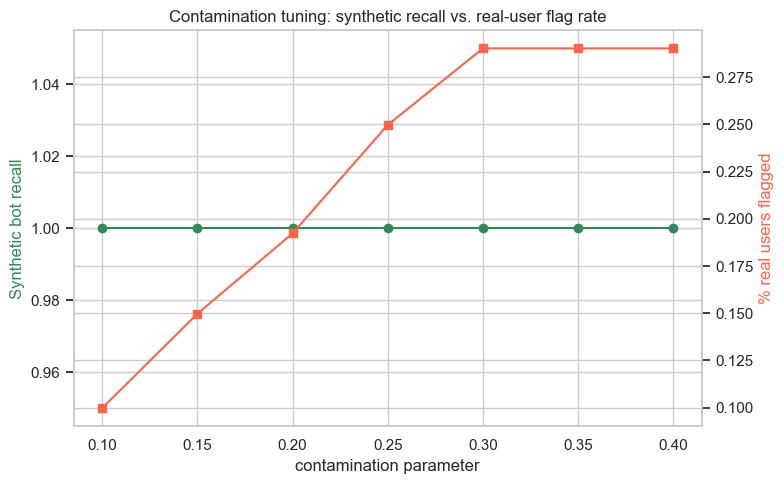

In [18]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(tuning_table['contamination'], tuning_table['synthetic_recall'], marker='o', color='seagreen', label='Synthetic bot recall')
ax1.set_xlabel('contamination parameter')
ax1.set_ylabel('Synthetic bot recall', color='seagreen')
ax2 = ax1.twinx()
ax2.plot(tuning_table['contamination'], tuning_table['real_flagged_rate'], marker='s', color='tomato', label='% real users flagged')
ax2.set_ylabel('% real users flagged', color='tomato')
plt.title('Contamination tuning: synthetic recall vs. real-user flag rate')
fig.tight_layout()
plt.show()


In [19]:
# Pick the smallest contamination that still achieves strong synthetic recall (>=0.95), to avoid over-flagging real users
qualifying = tuning_table[tuning_table['synthetic_recall'] >= 0.95]
BEST_CONTAMINATION = qualifying['contamination'].min() if len(qualifying) > 0 else tuning_table.loc[tuning_table['synthetic_recall'].idxmax(), 'contamination']

print(f"Selected contamination: {BEST_CONTAMINATION}")
print(tuning_table[tuning_table['contamination'] == BEST_CONTAMINATION])


Selected contamination: 0.1
   contamination  synthetic_recall  real_flagged_rate
0            0.1               1.0           0.099668


## Stage 4c — Fit the final Isolation Forest (on real data only)

In [20]:
iso_forest = IsolationForest(
    n_estimators=300, contamination=BEST_CONTAMINATION, random_state=RANDOM_STATE, n_jobs=-1
)
agg['anomaly_flag'] = iso_forest.fit_predict(X_scaled)
agg['anomaly_score'] = iso_forest.score_samples(X_scaled)
agg['is_abnormal'] = agg['anomaly_flag'] == -1

print("Flagged abnormal (pre-override):", agg['is_abnormal'].sum(), f"({agg['is_abnormal'].mean()*100:.1f}%)")


Flagged abnormal (pre-override): 140750 (10.0%)


## Stage 5 — Cross-validation: independent agreement checks

### Method 2: Rule-based conjunction (AND logic across independent signals, not a simple sum)

A visitor is flagged by this rule only if **multiple independent conditions hold simultaneously** — matching our earlier discussion that any single signal alone has an innocent explanation.


In [21]:
def robust_z(series):
    median = series.median()
    mad = (series - median).abs().median()
    mad = mad if mad > 0 else 1e-9
    return (series - median) / (1.4826 * mad)   # 1.4826 makes MAD comparable to std under normality

z_speed = -robust_z(X['avg_inter_click_gap'])          # low gap -> high suspicion
z_rate = robust_z(X['views_per_minute'])
z_regularity = -robust_z(X['timing_regularity_cv'])     # low CV -> high suspicion
z_volume = robust_z(X['total_events'])
zero_conversion = (agg['n_addtocart'] == 0) & (agg['n_transactions'] == 0)

rule_based_flag = (
    (z_speed > 3) & (z_rate > 3) & (z_regularity > 3) & (z_volume > 3) & zero_conversion
)
agg['rule_based_abnormal'] = rule_based_flag

print("Rule-based flags:", rule_based_flag.sum(), f"({rule_based_flag.mean()*100:.2f}%)")


Rule-based flags: 31777 (2.26%)


### Method 3: Local Outlier Factor (LOF) — third independent opinion, on a sample for speed

In [22]:
SAMPLE_SIZE = 50000
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(SAMPLE_SIZE, len(X_scaled)), replace=False)

lof = LocalOutlierFactor(n_neighbors=20, contamination=BEST_CONTAMINATION)
lof_flags_sample = lof.fit_predict(X_scaled[sample_idx])

agg_sample = agg.iloc[sample_idx].copy()
agg_sample['lof_abnormal'] = lof_flags_sample == -1

iso_vs_lof_agreement = (agg_sample['is_abnormal'] == agg_sample['lof_abnormal']).mean()
print(f"Isolation Forest vs LOF agreement (on {SAMPLE_SIZE:,}-user sample): {iso_vs_lof_agreement*100:.1f}%")


c:\Users\akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Isolation Forest vs LOF agreement (on 50,000-user sample): 92.1%


In [23]:
iso_vs_rule_overlap = (agg['is_abnormal'] & agg['rule_based_abnormal']).sum() / max(agg['rule_based_abnormal'].sum(), 1)
print(f"Of users flagged by the strict rule-based method, % also flagged by Isolation Forest: {iso_vs_rule_overlap*100:.1f}%")
print("(The rule-based method is deliberately strict/conservative -- high overlap here means Isolation Forest")
print(" is capturing the same high-confidence cases, not just noise.)")


Of users flagged by the strict rule-based method, % also flagged by Isolation Forest: 45.1%
(The rule-based method is deliberately strict/conservative -- high overlap here means Isolation Forest
 is capturing the same high-confidence cases, not just noise.)


## Stage 6 — Feature separation check (sanity, not just statistics)

With the sentinel-value bug fixed, this comparison should now show *behaviourally meaningful* gaps, not an artifact.


In [24]:
separation = agg.groupby('is_abnormal')[feature_cols].median().T
separation.columns = ['Normal (median)', 'Abnormal (median)']
separation


,Normal (median),Abnormal (median)
total_events,1.000000,5.000000
n_views,1.000000,5.000000
n_addtocart,0.000000,0.000000
n_transactions,0.000000,0.000000
unique_items,1.000000,3.000000
item_diversity_ratio,1.000000,0.571429
view_to_cart_ratio,0.000000,0.000000
cart_to_transaction_ratio,0.000000,0.000000
avg_inter_click_gap,77.486750,143.202156
views_per_minute,1.407726,0.823091


In [25]:
sil_score = silhouette_score(X_scaled, agg['anomaly_flag'], sample_size=20000, random_state=RANDOM_STATE)
print(f"Silhouette Score: {sil_score:.4f}")


Silhouette Score: 0.6887


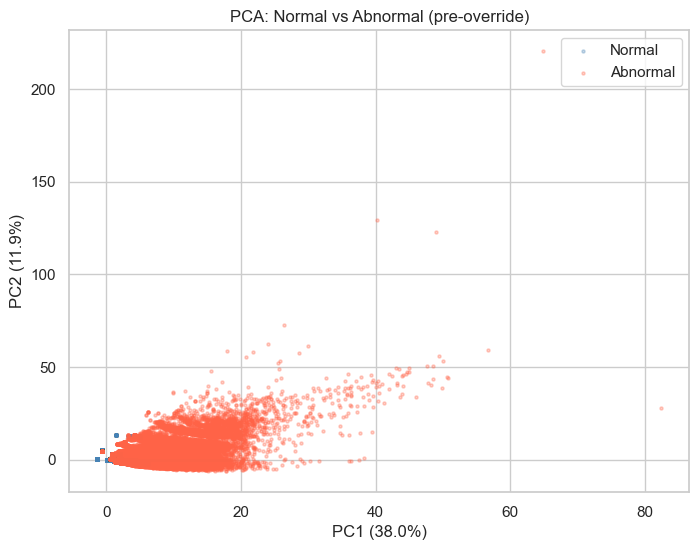

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[~agg['is_abnormal'], 0], X_pca[~agg['is_abnormal'], 1], s=5, alpha=0.3, label='Normal', color='steelblue')
plt.scatter(X_pca[agg['is_abnormal'], 0], X_pca[agg['is_abnormal'], 1], s=5, alpha=0.3, label='Abnormal', color='tomato')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: Normal vs Abnormal (pre-override)')
plt.legend()
plt.show()


## Stage 7 — Business-rule override

No visitor who ever converts (`addtocart` or `transaction`) can be treated as abnormal, regardless of model score.


In [27]:
converting_visitors = (agg['n_addtocart'] > 0) | (agg['n_transactions'] > 0)
overridden_count = (agg['is_abnormal'] & converting_visitors).sum()

agg.loc[converting_visitors, 'is_abnormal'] = False

print(f"Visitors overridden back to 'normal' because they converted: {overridden_count:,}")
print(f"Final abnormal users: {agg['is_abnormal'].sum():,} ({agg['is_abnormal'].mean()*100:.1f}% of all users)")


Visitors overridden back to 'normal' because they converted: 36,691
Final abnormal users: 104,059 (7.4% of all users)


## Stage 8 — Event-level cleaning

Only `view` events belonging to abnormal visitors are removed. `addtocart`/`transaction` are already protected by the Stage 7 override, but we filter at the event level too as a second safeguard.


In [28]:
abnormal_visitor_ids = agg.loc[agg['is_abnormal'], 'visitorid']

rows_to_remove = events['visitorid'].isin(abnormal_visitor_ids) & (events['event'] == 'view')
events_clean_final = events[~rows_to_remove].copy()

pct_users_removed = agg['is_abnormal'].mean() * 100
pct_events_removed = rows_to_remove.mean() * 100

print(f"% of USERS flagged abnormal : {pct_users_removed:.1f}%")
print(f"% of EVENTS (views) removed : {pct_events_removed:.1f}%")
print(f"Addtocart events kept: {(events_clean_final['event']=='addtocart').sum():,} (should equal original count)")
print(f"Transactions kept    : {(events_clean_final['event']=='transaction').sum():,} (should equal original count)")


% of USERS flagged abnormal : 7.4%
% of EVENTS (views) removed : 25.7%
Addtocart events kept: 69,332 (should equal original count)
Transactions kept    : 22,457 (should equal original count)


## Stage 9 — Reporting & export

In [29]:
before_mix = events['event'].value_counts(normalize=True).rename('before_cleaning')
after_mix = events_clean_final['event'].value_counts(normalize=True).rename('after_cleaning')
mix_comparison = pd.concat([before_mix, after_mix], axis=1)
mix_comparison


,before_cleaning,after_cleaning
event,,
view,0.966696,0.955190
addtocart,0.025156,0.033847
transaction,0.008148,0.010963


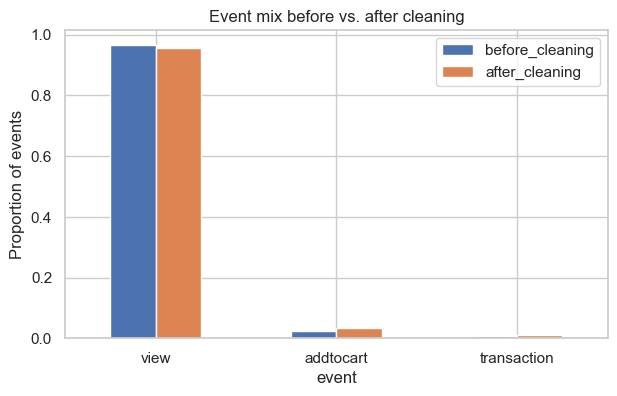

In [30]:
mix_comparison.plot(kind='bar', figsize=(7,4))
plt.title('Event mix before vs. after cleaning')
plt.ylabel('Proportion of events')
plt.xticks(rotation=0)
plt.show()


In [31]:
summary = pd.DataFrame({
    'Metric': [
        'Selected contamination',
        'Synthetic bot recall at selected contamination',
        '% users flagged abnormal (final, post-override)',
        '% events (views) removed',
        'Silhouette Score',
        'Isolation Forest vs LOF agreement',
        'Isolation Forest vs strict rule-based overlap',
    ],
    'Value': [
        BEST_CONTAMINATION,
        tuning_table.loc[tuning_table['contamination'] == BEST_CONTAMINATION, 'synthetic_recall'].values[0],
        pct_users_removed,
        pct_events_removed,
        sil_score,
        iso_vs_lof_agreement,
        iso_vs_rule_overlap,
    ]
})
summary


,Metric,Value
0,Selected contamination,0.100000
1,Synthetic bot recall at selected contamination,1.000000
2,"% users flagged abnormal (final, post-override)",7.392759
3,% events (views) removed,25.677143
4,Silhouette Score,0.688747
5,Isolation Forest vs LOF agreement,0.920880
6,Isolation Forest vs strict rule-based overlap,0.451270


In [32]:
events_clean_final.drop(columns=['session_id', 'intra_session_gap_sec', 'hour', 'is_night'], errors='ignore').to_csv(
    'events_clean_FINAL.csv', index=False
)

print("Saved: events_clean_FINAL.csv")


Saved: events_clean_FINAL.csv
